# 📊 Projeto: Regressão e Machine Learning com Apache Spark

## 🧠 1. Compreendendo o Ecossistema Apache Spark

O **Apache Spark** é o motor de código aberto mais poderoso do mercado para o processamento de dados em larga escala (**Big Data**). Diferente dos frameworks tradicionais (como o Pandas), que processam dados sequencialmente na memória RAM de uma única máquina, o Spark utiliza uma **arquitetura distribuída**.

### ⚙️ Características Principais do Motor:
* **Processamento In-Memory:** Executa cálculos em memória RAM até 100x mais rápido que o ecossistema Hadoop MapReduce tradicional.
* **Avaliação Preguiçosa (Lazy Evaluation):** O Spark cria um plano de execução ideal (DAG) e só processa os dados de verdade quando um comando de ação (como `.show()` ou `.count()`) é disparado.
* **Escalabilidade:** Permite ler, tratar e aplicar modelos de Machine Learning em arquivos gigantescos (JSON, Parquet, CSV) de forma extremamente veloz.


In [100]:
import os
import sys
from pyspark.sql import SparkSession

# 1. Configura os caminhos físicos exatos do seu computador (Java 11.0.31.11 e Hadoop)
os.environ["JAVA_HOME"] = r"C:\Program Files\Microsoft\jdk-11.0.31.11-hotspot"
os.environ["HADOOP_HOME"] = r"C:\hadoop"

# 2. Injeta a pasta do PySpark do seu ambiente virtual (.venv) na memória do Python
caminho_pyspark = os.path.join(sys.prefix, 'Lib', 'site-packages', 'pyspark')
os.environ["SPARK_HOME"] = caminho_pyspark
os.environ["PATH"] = os.environ["PATH"] + ";" + os.path.join(caminho_pyspark, 'bin')

# 3. Inicializa a sessão do Spark (Mantendo o AppName e as configurações da aula, com bypass de rede)
spark = SparkSession.builder \
    .master('local[*]') \
    .appName("Regressão com Spark") \
    .config("spark.driver.host", "localhost") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.ui.enabled", "false") \
    .config("spark.sql.warehouse.dir", "file:///C:/hadoop/warehouse") \
    .getOrCreate()

# 4. CORRIGIDO: Usa o print de texto comum para evitar o bug visual do VS Code!
print("🏆 SUCESSO ABSOLUTO! O motor local do Spark inicializou perfeito!")
print(spark)


🏆 SUCESSO ABSOLUTO! O motor local do Spark inicializou perfeito!


In [101]:
# No VS Code local, o Spark lê direto da sua pasta física do projeto!
dados_brutos = spark.read.json("dados/imoveis.json")

print("📋 Estrutura de colunas do DataFrame:")
dados_brutos.printSchema()

print("\n👀 Visualização das primeiras 5 linhas:")
dados_brutos.show(5, truncate=False)


📋 Estrutura de colunas do DataFrame:
root
 |-- ident: struct (nullable = true)
 |    |-- customerID: string (nullable = true)
 |    |-- source: string (nullable = true)
 |-- listing: struct (nullable = true)
 |    |-- address: struct (nullable = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- location: struct (nullable = true)
 |    |    |    |-- lat: double (nullable = true)
 |    |    |    |-- lon: double (nullable = true)
 |    |    |-- neighborhood: string (nullable = true)
 |    |    |-- zone: string (nullable = true)
 |    |-- features: struct (nullable = true)
 |    |    |-- bathrooms: long (nullable = true)
 |    |    |-- bedrooms: long (nullable = true)
 |    |    |-- floors: long (nullable = true)
 |    |    |-- parkingSpaces: long (nullable = true)
 |    |    |-- suites: long (nullable = true)
 |    |    |-- totalAreas: string (nullable = true)
 |    |    |-- unitFloor: long (nullable = true)
 |    |    |-- unitsOnTheFloor: long (nullable = true)
 |    |  

In [102]:
# 1. Lê o JSON local salvando o resultado na variável 'dados' (conforme a aula)
dados = spark.read.json("dados/imoveis.json")

# 2. Exibe as primeiras 5 linhas para você confirmar o sucesso
dados.show(5, truncate=False)


+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ident                     |listing                                                                                                                                                          |
+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{775564-BOJSMVON, Website}|{{Rio de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Oeste}, {0, 0, 0, 1, 0, 62, 0, 0, 62}, {45000, {150, 0}}, {Outros, Residencial}}                       |
|{660895-AUENKNYY, Website}|{{Rio de Janeiro, {-22.869698, -43.509141}, Santíssimo, Zona Oeste}, {1, 2, 0, 1, 0, 0, 0, 0, 44}, {45000, {120, 0}}, {Apartamento, Residencial}}                |
|{751522-JESYFEQL, Website}|{{Rio de Janeiro,

In [103]:
dados.show(truncate=False)

+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ident                     |listing                                                                                                                                                          |
+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{775564-BOJSMVON, Website}|{{Rio de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Oeste}, {0, 0, 0, 1, 0, 62, 0, 0, 62}, {45000, {150, 0}}, {Outros, Residencial}}                       |
|{660895-AUENKNYY, Website}|{{Rio de Janeiro, {-22.869698, -43.509141}, Santíssimo, Zona Oeste}, {1, 2, 0, 1, 0, 0, 0, 0, 44}, {45000, {120, 0}}, {Apartamento, Residencial}}                |
|{751522-JESYFEQL, Website}|{{Rio de Janeiro,

In [104]:
dados.count()


73615

In [105]:
dados.printSchema()

root
 |-- ident: struct (nullable = true)
 |    |-- customerID: string (nullable = true)
 |    |-- source: string (nullable = true)
 |-- listing: struct (nullable = true)
 |    |-- address: struct (nullable = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- location: struct (nullable = true)
 |    |    |    |-- lat: double (nullable = true)
 |    |    |    |-- lon: double (nullable = true)
 |    |    |-- neighborhood: string (nullable = true)
 |    |    |-- zone: string (nullable = true)
 |    |-- features: struct (nullable = true)
 |    |    |-- bathrooms: long (nullable = true)
 |    |    |-- bedrooms: long (nullable = true)
 |    |    |-- floors: long (nullable = true)
 |    |    |-- parkingSpaces: long (nullable = true)
 |    |    |-- suites: long (nullable = true)
 |    |    |-- totalAreas: string (nullable = true)
 |    |    |-- unitFloor: long (nullable = true)
 |    |    |-- unitsOnTheFloor: long (nullable = true)
 |    |    |-- usableAreas: string (nullable =

In [106]:
dados\
    .select('ident.customerID', 'listing.*')\
    .show(truncate=False)

+---------------+--------------------------------------------------------------------------------+-------------------------------+---------------------+--------------------------+
|customerID     |address                                                                         |features                       |prices               |types                     |
+---------------+--------------------------------------------------------------------------------+-------------------------------+---------------------+--------------------------+
|775564-BOJSMVON|{Rio de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Oeste}                 |{0, 0, 0, 1, 0, 62, 0, 0, 62}  |{45000, {150, 0}}    |{Outros, Residencial}     |
|660895-AUENKNYY|{Rio de Janeiro, {-22.869698, -43.509141}, Santíssimo, Zona Oeste}              |{1, 2, 0, 1, 0, 0, 0, 0, 44}   |{45000, {120, 0}}    |{Apartamento, Residencial}|
|751522-JESYFEQL|{Rio de Janeiro, {-22.986927, -43.646786}, Pedra de Guaratiba, Zona Oeste}      |{0

In [107]:
dados\
    .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
    .drop('city', 'location', 'totalAreas')\
    .show(truncate=False)

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+------------------------+------------+-----+-----+----+
|customerID     |unit       |usage      |bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood            |zone        |price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+------------------------+------------+-----+-----+----+
|775564-BOJSMVON|Outros     |Residencial|0        |0       |0     |1            |0     |0        |0              |62         |Taquara                 |Zona Oeste  |45000|150  |0   |
|660895-AUENKNYY|Apartamento|Residencial|1        |2       |0     |1            |0     |0        |0              |44         |Santíssimo              |Zona Oeste  |45000|120  |0   |
|751522-JESYFEQL|Outros     |Residencial|0        |0       |0     |0            |0     |0 

In [108]:
dataset = dados\
    .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
    .drop('city', 'location', 'totalAreas')

In [109]:
dataset.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: string (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: string (nullable = true)
 |-- condo: string (nullable = true)
 |-- iptu: string (nullable = true)



In [110]:
from pyspark.sql.types import IntegerType, DoubleType

In [111]:
dataset\
    .withColumn('usableAreas', dataset['usableAreas'].cast(IntegerType()))\
    .withColumn('price', dataset['price'].cast(DoubleType()))\
    .withColumn('condo', dataset['condo'].cast(DoubleType()))\
    .withColumn('iptu', dataset['iptu'].cast(DoubleType()))\
    .printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: double (nullable = true)
 |-- condo: double (nullable = true)
 |-- iptu: double (nullable = true)



In [112]:
dataset = dataset\
    .withColumn('usableAreas', dataset['usableAreas'].cast(IntegerType()))\
    .withColumn('price', dataset['price'].cast(DoubleType()))\
    .withColumn('condo', dataset['condo'].cast(DoubleType()))\
    .withColumn('iptu', dataset['iptu'].cast(DoubleType()))

In [113]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo|  iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|   0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|   0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|  

In [114]:
dataset\
    .select('usage')\
    .groupBy('usage')\
    .count()\
    .show()

+-----------+-----+
|      usage|count|
+-----------+-----+
|  Comercial| 4019|
|Residencial|69596|
+-----------+-----+



In [115]:
dataset = dataset\
    .select('*')\
    .where('usage=="Residencial"')

In [116]:
dataset\
    .select('unit')\
    .groupBy('unit')\
    .count()\
    .show()

+-----------+-----+
|       unit|count|
+-----------+-----+
|     Outros| 1190|
|Apartamento|59106|
|       Casa| 9300|
+-----------+-----+



In [117]:
dataset\
    .select('zone')\
    .groupBy('zone')\
    .count()\
    .show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
|            |  157|
+------------+-----+



In [118]:
from pyspark.sql import functions as f

In [119]:
dataset\
    .select([f.count(f.when(f.isnan(c) | f.isnull(c), True)).alias(c) for c in dataset.columns])\
    .show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0| 6061|8726|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



In [120]:
dataset\
    .select('*')\
    .na\
    .fill(0)\
    .show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

In [121]:
dataset = dataset\
    .select('*')\
    .na\
    .fill(0)

In [122]:
dataset\
    .select([f.count(f.when(f.isnan(c) | f.isnull(c), True)).alias(c) for c in dataset.columns])\
    .show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0|    0|   0|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



In [123]:
dataset\
    .select('zone')\
    .groupBy('zone')\
    .count()\
    .show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
|            |  157|
+------------+-----+



In [124]:
dataset = dataset\
    .where(f.col('zone') != '')

### **Processos de Machine Learning** 
::

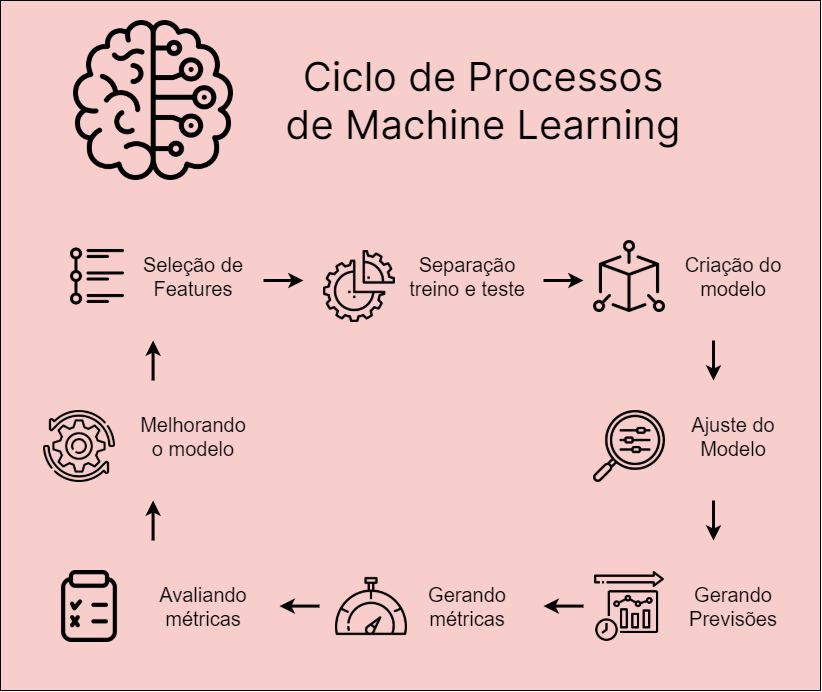

In [125]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

In [126]:
dataset\
    .groupBy("customerID")\
    .pivot('unit')\
    .agg(f.lit(1))\
    .na\
    .fill(0)\
    .show()

+---------------+-----------+----+------+
|     customerID|Apartamento|Casa|Outros|
+---------------+-----------+----+------+
|062130-QKYMWGMV|          1|   0|     0|
|630945-AEEUPRXI|          0|   1|     0|
|994985-OZQNHQKH|          1|   0|     0|
|494674-JWXRZIBM|          1|   0|     0|
|458844-UJCRFSRI|          1|   0|     0|
|155284-BRCDAOIQ|          1|   0|     0|
|396742-DUXBHLRU|          1|   0|     0|
|916072-ZJXARAXO|          1|   0|     0|
|943843-BVTWWHRQ|          1|   0|     0|
|193126-MTNIIFQN|          1|   0|     0|
|319762-UXTTQYFS|          1|   0|     0|
|931151-GZCTKADB|          1|   0|     0|
|103840-OFKPFEZJ|          0|   1|     0|
|176885-NNKZRQGM|          0|   1|     0|
|926638-PBYRAZYR|          1|   0|     0|
|744421-IZJWISWB|          1|   0|     0|
|530012-TYGLQMER|          1|   0|     0|
|209407-GTEUOVKR|          1|   0|     0|
|289667-ZPHGFHJH|          1|   0|     0|
|859388-EYTPMKER|          1|   0|     0|
+---------------+-----------+----+

In [127]:
unit = dataset\
    .groupBy('customerID')\
    .pivot('unit')\
    .agg(f.lit(1))\
    .na\
    .fill(0)

In [128]:
zone = dataset\
    .groupBy('customerID')\
    .pivot('zone')\
    .agg(f.lit(1))\
    .na\
    .fill(0)

In [129]:
dataset = dataset\
    .join(unit, 'customerID', how='inner')\
    .join(zone, 'customerID', how='inner')

In [130]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [131]:
from pyspark.ml.feature import VectorAssembler

In [132]:
dataset = dataset.withColumnRenamed('price','label')

In [133]:
X = [

    'bathrooms',

    'bedrooms',

    'floors',

    'parkingSpaces',

    'suites',

    'unitFloor',

    'unitsOnTheFloor',

    'usableAreas',

    'condo',

    'iptu',

    'Apartamento',

    'Casa',

    'Outros',

    'Zona Central',

    'Zona Norte',

    'Zona Oeste',

    'Zona Sul'

]

In [134]:
assembler = VectorAssembler(inputCols = X, outputCol = 'features')

In [135]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  label|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [136]:
dataset_prep = assembler.transform(dataset).select('features', 'label')

In [137]:
dataset_prep.show(10, truncate=False)

+--------------------------------------------------------------------------+-------+
|features                                                                  |label  |
+--------------------------------------------------------------------------+-------+
|(17,[3,7,8,12,15],[1.0,62.0,150.0,1.0,1.0])                               |45000.0|
|(17,[0,1,3,7,8,10,15],[1.0,2.0,1.0,44.0,120.0,1.0,1.0])                   |45000.0|
|(17,[7,8,12,15],[132.0,100.0,1.0,1.0])                                    |50000.0|
|[2.0,3.0,3.0,1.0,1.0,2.0,4.0,60.0,400.0,120.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0]|50000.0|
|(17,[7,12,15],[200.0,1.0,1.0])                                            |50000.0|
|(17,[0,1,3,7,10,14],[1.0,1.0,1.0,33.0,1.0,1.0])                           |45336.0|
|(17,[7,12,15],[120.0,1.0,1.0])                                            |45000.0|
|(17,[7,12,15],[468.0,1.0,1.0])                                            |45000.0|
|(17,[5,7,12,15],[1.0,180.0,1.0,1.0])                            

# 📈 Engenharia de Recursos: Variáveis Dummy (One-Hot Encoding)

## 🧠 1. O Conceito de Variável Dummy

A grande maioria dos algoritmos de Machine Learning (como a Regressão Linear do Spark) é puramente matemática e só consegue processar **dados numéricos**. Quando a base de dados possui colunas categóricas (textos como *Bairro*, *Tipo de Imóvel* ou *Região*), é necessário transformá-las em números. 

A abordagem padrão e mais eficiente do mercado para resolver isso é o conceito de **Variável Dummy**. Este processo consiste em transformar colunas de texto em **variáveis binárias** (contendo apenas os valores `0` ou `1`).

### ⚙️ Como funciona a transformação na prática:
* **Duas Categorias:** Se a coluna possui apenas duas classes (ex: Sim/Não), basta substituir uma classe por `0` e a outra por `1`.
* **Múltiplas Categorias:** Se a coluna possuir mais de duas classes (ex: Zona Sul, Zona Oeste, Zona Norte), o algoritmo cria **uma nova coluna para cada categoria existente**. O registro recebe o valor `1` na coluna correspondente à sua classe real, e recebe `0` em todas as outras colunas criadas.

---

## ⚠️ 2. A Importância de Evitar a Ponderação Arbitrária

Um erro muito comum em projetos de dados iniciantes é substituir categorias por números sequenciais (ex: *Zona Oeste = 1*, *Zona Sul = 2*, *Zona Norte = 3*). 

Este procedimento é chamado de **Ponderação Arbitrária** e gera graves problemas de modelagem:
1. **Criação de Viés:** Ao colocar números sequenciais, você força o modelo de Machine Learning a acreditar que a *Zona Norte (3)* é três vezes maior ou mais importante que a *Zona Oeste (1)*, ou que existe uma ordem/hierarquia entre os bairros.
2. **Distorção da Realidade:** Atribui pesos matemáticos totalmente artificiais que não correspondem aos valores reais do mercado de imóveis.

Portanto, para garantir a precisão matemática do modelo de Regressão, **sempre utiliza-se variáveis dummy** para mapear dados categóricos sem criar falsas relações de ordem.


In [138]:
from pyspark.ml.stat import Correlation
import pandas as pd

correlacao = Correlation.corr(dataset_prep, 'features').collect()

correlacao

[Row(pearson(features)=DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False))]

In [139]:
correlacao = Correlation.corr(dataset_prep, 'features').collect()[0][0]

In [140]:
correlacao.toArray()

array([[ 1.00000000e+00,  6.65910814e-01, -4.45907541e-02,
         4.87590447e-01,  7.52927830e-01,  7.62425469e-03,
        -1.07437445e-01,  5.98072790e-01,  2.00298945e-02,
         1.51023977e-02, -2.75457964e-01,  3.43042378e-01,
        -1.40183420e-01, -9.73678190e-02, -1.62497441e-01,
         2.42345124e-01, -9.87517576e-02],
       [ 6.65910814e-01,  1.00000000e+00, -8.21840063e-02,
         4.67161260e-01,  6.01199220e-01, -7.16195849e-03,
        -1.30814438e-01,  5.63750247e-01,  1.84819307e-02,
         1.36391535e-02, -2.58339018e-01,  3.49962189e-01,
        -2.05607705e-01, -1.23732152e-01, -1.11711865e-01,
         1.63821698e-01, -4.94325200e-02],
       [-4.45907541e-02, -8.21840063e-02,  1.00000000e+00,
        -4.84861921e-02, -4.81062141e-02,  1.20981700e-01,
         7.37717422e-01, -1.03916850e-01,  1.37973623e-02,
         6.68849447e-03,  1.53947015e-01, -1.42089598e-01,
        -5.19462291e-02,  1.26044467e-01, -1.69262936e-02,
        -3.17495417e-02,  1.7

In [141]:
dataframe_correlacao = pd.DataFrame(correlacao.toArray(), columns=X, index=X)

dataframe_correlacao

,bathrooms,bedrooms,floors,parkingSpaces,suites,unitFloor,unitsOnTheFloor,usableAreas,condo,iptu,Apartamento,Casa,Outros,Zona Central,Zona Norte,Zona Oeste,Zona Sul
bathrooms,1.000000,0.665911,-0.044591,0.487590,0.752928,0.007624,-0.107437,0.598073,0.020030,0.015102,-0.275458,0.343042,-0.140183,-0.097368,-0.162497,0.242345,-0.098752
bedrooms,0.665911,1.000000,-0.082184,0.467161,0.601199,-0.007162,-0.130814,0.563750,0.018482,0.013639,-0.258339,0.349962,-0.205608,-0.123732,-0.111712,0.163822,-0.049433
floors,-0.044591,-0.082184,1.000000,-0.048486,-0.048106,0.120982,0.737717,-0.103917,0.013797,0.006688,0.153947,-0.142090,-0.051946,0.126044,-0.016926,-0.031750,0.017402
parkingSpaces,0.487590,0.467161,-0.048486,1.000000,0.484988,0.003768,-0.074527,0.483732,0.018012,0.009721,-0.252746,0.293326,-0.072359,-0.086437,-0.109957,0.267990,-0.178807
suites,0.752928,0.601199,-0.048106,0.484988,1.000000,0.005206,-0.091914,0.577636,0.023461,0.019093,-0.236217,0.282221,-0.088834,-0.084417,-0.230317,0.327546,-0.136398
unitFloor,0.007624,-0.007162,0.120982,0.003768,0.005206,1.000000,0.092359,-0.012748,0.003065,0.001200,0.034674,-0.031403,-0.013275,0.022315,-0.011112,0.007518,-0.004333
unitsOnTheFloor,-0.107437,-0.130814,0.737717,-0.074527,-0.091914,0.092359,1.000000,-0.144222,-0.000554,0.005029,0.147497,-0.137754,-0.045523,0.153639,0.030753,-0.012434,-0.055540
usableAreas,0.598073,0.563750,-0.103917,0.483732,0.577636,-0.012748,-0.144222,1.000000,0.019717,0.014656,-0.482170,0.459136,0.125672,-0.075256,-0.158553,0.192466,-0.051962
condo,0.020030,0.018482,0.013797,0.018012,0.023461,0.003065,-0.000554,0.019717,1.000000,0.226212,0.009105,-0.008624,-0.002495,-0.003553,-0.013453,-0.001055,0.014474
iptu,0.015102,0.013639,0.006688,0.009721,0.019093,0.001200,0.005029,0.014656,0.226212,1.000000,-0.001502,0.002291,-0.001870,-0.002438,-0.008400,-0.000428,0.008835


In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

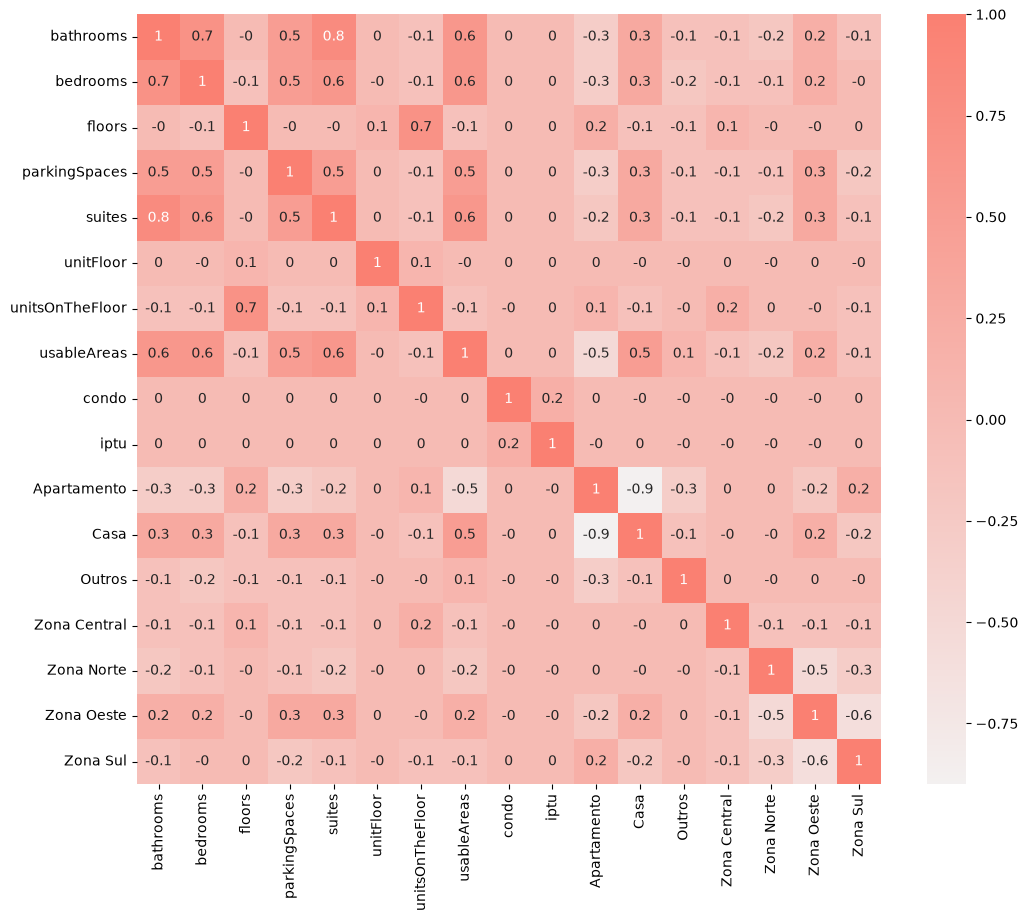

In [143]:
plt.figure(figsize=(12,10))
paleta = sns.color_palette("light:salmon", as_cmap=True)
sns.heatmap(dataframe_correlacao.round(1), annot=True, cmap=paleta)

# 📉 Análise Estatística: Entendendo a Multicolinearidade

## 🧠 1. O Conceito de Multicolinearidade

Nos modelos de regressão, o algoritmo estima coeficientes matemáticos para cada variável explicativa (como número de quartos, banheiros e área útil) para conseguir prever o preço final do imóvel. No entanto, pode ocorrer um problema estatístico clássico chamado **Multicolinearidade**.

A multicolinearidade refere-se à **alta correlação entre duas ou mais variáveis explicativas** dentro do modelo. Quando essa correlação é excessivamente alta, a eficiência dos coeficientes matemáticos diminui, super-inflacionando os erros padrão e aumentando a variância das estimativas. Na prática, isso pode fazer com que variáveis estatisticamente importantes pareçam insignificantes para o modelo.

### 📊 Os Três Casos Principais:
1. **Ausência de Multicolinearidade:** Ocorre quando a correlação entre as variáveis explicativas é nula. Este é o cenário ideal para a matemática da regressão.
2. **Multicolinearidade Perfeita:** Ocorre quando a correlação entre as variáveis é igual a `1` ou `-1`. Sob estas circunstâncias, o cálculo dos parâmetros torna-se matematicamente impossível.
3. **Multicolinearidade Imperfeita:** Ocorre quando a correlação está situada entre `0` e `1`, ou entre `-1` e `0`. Este é o cenário mais comum em bases de dados reais.

---

## 🛠️ 2. A Solução na Engenharia de Dados

Caso duas ou mais variáveis apresentem uma correlação linear muito alta entre si, elas acabam se tornando **ambíguas**, ou seja, explicam exatamente o mesmo comportamento dos dados (ex: se um imóvel possui uma área útil gigante, ele quase sempre terá uma área total proporcionalmente gigante).

Para mitigar esse problema e garantir a estabilidade matemática dos coeficientes da Regressão, a melhor prática consiste em identificar essas variáveis altamente correlacionadas e **remover uma delas do treinamento do modelo**.


In [144]:
from pyspark.ml.regression import LinearRegression

In [145]:
treino, teste = dataset_prep.randomSplit([0.7, 0.3], seed=101)

In [146]:
treino.count() 


48528

In [147]:
teste.count()


20911

In [148]:
lr = LinearRegression()

In [149]:
modelo_lr = lr.fit(treino)

In [150]:
previsoes_lr_treino = modelo_lr.transform(treino)

previsoes_lr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0|443266.04735414364|
|(17,[0,1,2,3,4,5,...|500000.0| 1127455.830038132|
|(17,[0,1,2,3,4,5,...|308615.0|111210.49949617946|
|(17,[0,1,2,3,4,5,...|279000.0|113587.95787201478|
|(17,[0,1,2,3,4,5,...|545000.0|340703.71307275613|
|(17,[0,1,2,3,4,5,...|449000.0|390571.99594633357|
|(17,[0,1,2,3,4,5,...|479000.0|444003.42971170257|
|(17,[0,1,2,3,4,5,...|420000.0| 720022.1542152823|
|(17,[0,1,2,3,4,5,...|265000.0|519406.05037327117|
|(17,[0,1,2,3,4,5,...|490000.0| 845483.5388422643|
|(17,[0,1,2,3,4,5,...|650000.0| 644931.4982469564|
|(17,[0,1,2,3,4,5,...|379900.0| 448889.3338994068|
|(17,[0,1,2,3,4,5,...|449000.0| 714548.9501067235|
|(17,[0,1,2,3,4,5,...|190000.0| 411726.9411594973|
|(17,[0,1,2,3,4,5,...|896000.0|   597499.46015323|
|(17,[0,1,2,3,4,5,...|679000.0| 864544.0129230723|
|(17,[0,1,2,3,4,5,...|620000.0|

In [151]:
resumo_treino = modelo_lr.summary

In [152]:
resumo_treino.r2

0.6655873678454561

In [153]:
resumo_treino.rootMeanSquaredError


810348.9695316249

In [154]:
resumo_teste = modelo_lr.evaluate(teste)

In [155]:
resumo_teste.r2

0.6585207937773889

In [156]:
resumo_teste.rootMeanSquaredError

800525.9696829222

In [157]:
print('Linear Regression')
print("="*30)
print("Dados de Treino")
print("="*30)
print("R²: %f" % resumo_treino.r2)
print("RMSE: %f" % resumo_treino.rootMeanSquaredError)
print("")
print("="*30)
print("Dados de Teste")
print("="*30)
print("R²: %f" % resumo_teste.r2)
print("RMSE: %f" % resumo_teste.rootMeanSquaredError)

Linear Regression
Dados de Treino
R²: 0.665587
RMSE: 810348.969532

Dados de Teste
R²: 0.658521
RMSE: 800525.969683


# 🌲 Modelagem Preditiva: Árvore de Decisão para Regressão

## 🧠 1. Como Funciona o Algoritmo

A **Árvore de Decisão (*Decision Tree*)** é um algoritmo de Machine Learning que resolve problemas de regressão dividindo a base de dados em partes menores através de perguntas lógicas seguidas (regras de decisão). O objetivo é segmentar os dados para fazer previsões com base nas características do imóvel.

### ⚙️ Estrutura de Divisão:
* **Nó Inicial (Raiz):** É a primeira grande pergunta que o algoritmo faz para separar a base de dados (no exemplo: `n_quartos > 5`).
* **Ramificações (Sim / Não):** Se o imóvel atende ao critério do nó, ele segue pelo caminho da esquerda (*Sim*); caso contrário, ele segue pelo caminho da direita (*Não*).
* **Nós Filhos (Decisões Seguintes):** A partir da primeira resposta, novas perguntas específicas são feitas para refinar a previsão (ex: avaliar se a `area > 1200` para imóveis grandes, ou checar o `n_banheiros > 7` para os demais), até chegar no valor estimado do preço.


<img src='https://raw.githubusercontent.com/pedrohcmds/alura_testes/main/Árvore%20de%20Decisão%20-%20Regressão%20(2).gif'>

## 📊 2. Anatomia e Estrutura dos Nós da Árvore

Para entender como o algoritmo organiza os dados por completo, a estrutura é dividida em três tipos de nós principais:

### ⚙️ Componentes da Árvore:
* **Nó Raiz (Azul):** É o topo de tudo. Representa o ponto de partida do algoritmo, contendo a primeira regra ou pergunta que divide toda a base de dados original.
* **Sub-Nó de Decisão (Amarelo):** São os nós intermediários. Eles surgem quando um nó se divide em novos caminhos, contendo perguntas adicionais para continuar refinando os grupos de dados.
* **Nó Folha / Terminal (Verde):** São os pontos finais da árvore. Estes nós não se dividem mais. Na regressão, cada nó folha contém o resultado final da previsão (o preço estimado para os imóveis que chegaram até ali).


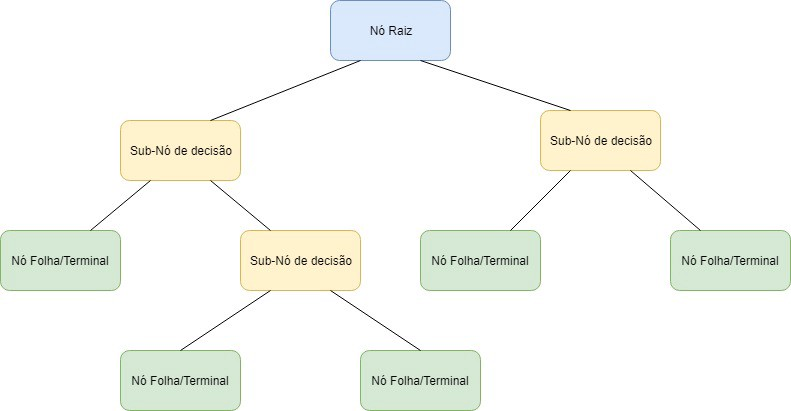

## 🌲 3. Critérios de Divisão de Nós: Redução de Variância

A grande vantagem da Árvore de Decisão é sua **alta explicabilidade**, permitindo compreender visualmente cada passo tomado até a previsão final. Para decidir qual é a melhor pergunta a ser feita em cada nó, o Apache Spark calcula numericamente a **Variância** dos dados.

### ⚙️ A Matemática por Trás da Divisão
A variância mede a dispersão dos dados em relação à média. O objetivo do algoritmo é testar várias divisões possíveis e escolher aquela que resulta na **menor variância combinada** entre os nós filhos, gerando subgrupos com características cada vez mais similares (homogêneos) entre si.

O cálculo simula a separação da seguinte forma:
1. O Spark escolhe uma variável explicativa e um ponto de corte (ex: `X <= 5.0`).
2. Separa as amostras entre o lado esquerdo e o lado direito.
3. Extrai a média da variável alvo ($y$) em cada novo nó formado.
4. Calcula a variância de cada lado. A estrutura final adota a divisão que minimizou esse indicador.

---

### 📊 Exemplo Prático de Tomada de Decisão

Considerando um cenário hipotético com os dados abaixo:
* **Variável Explicativa ($X$):** `[[0, 0], [2, 2], [4, 4], [6, 6], [8, 8], [10, 10], [12, 12]]`
* **Variável Alvo ($y$ - Preço):** `[0.5, 2.5, 4.5, 6.5, 8.5, 10.5, 12.5]`

Ao aplicar o critério de corte `X[0] <= 5.0`, o algoritmo divide o conjunto em:
* **Lado Esquerdo (3 amostras):** Variância obtida de `2.667`
* **Lado Direito (4 amostras):** Variância obtida de `5.0`
* **Variância Total da Divisão:** $2.667 + 5.0 = 7.667$

Como essa combinação gerou a menor variância possível entre todas as simulações testadas, o Spark a fixou como a regra do **Nó Raiz**.

### 📋 Regras de Predição Geradas no Modelo Final (Nós Folha):
A partir dos nós terminais (folhas), o modelo estabelece faixas exatas para as previsões com base nos intervalos calculados:
* Se a amostra de entrada estiver **entre 0 e 1**, o modelo prevê o valor **0.5**
* Se a amostra de entrada estiver **entre 1 e 5**, o modelo prevê o valor **3.5**
* Se a amostra de entrada for **maior que 5 e menor ou igual a 9**, o modelo prevê o valor **7.5**
* Se a amostra de entrada for **maior que 9**, o modelo prevê o valor **11.5**


In [158]:
from pyspark.ml.regression import DecisionTreeRegressor

In [159]:
dtr = DecisionTreeRegressor(seed=101, maxDepth=7)

In [160]:
modelo_dtr = dtr.fit(treino)

In [161]:
previsoes_dtr_treino = modelo_dtr.transform(treino)

In [162]:
previsoes_dtr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|500000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|308615.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|279000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|545000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|449000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|479000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|420000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|265000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|490000.0|  820272.937751004|
|(17,[0,1,2,3,4,5,...|650000.0|  736254.943802521|
|(17,[0,1,2,3,4,5,...|379900.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|449000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|190000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|896000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|679000.0|1158420.7653661144|
|(17,[0,1,2,3,4,5,...|620000.0|

In [163]:
from pyspark.ml.evaluation import RegressionEvaluator

In [164]:
evaluator = RegressionEvaluator()

print(evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: "r2"}))
print(evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: "rmse"}))

0.7930752588471226
637436.5434260432


In [165]:
previsoes_dtr_teste = modelo_dtr.transform(teste)

In [166]:
previsoes_dtr_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 350000.0|  820272.937751004|
|(17,[0,1,2,3,4,5,...| 340000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 430000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 600000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 439000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 333000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 948000.0|  736254.943802521|
|(17,[0,1,2,3,4,5,...| 459600.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 447600.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 360000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 407000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 310000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|1400000.0|1289301.4891122277|
|(17,[0,1,2,3,4,5,...|1180000.0|1289301.4891122277|
|(17,[0,1,2,3,4,5,...|1299500.0|1158420.7653661144|
|(17,[0,1,2,

In [167]:
print('Decision Tree Regression')
print("="*30)
print("Dados de Treino")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Dados de Teste")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: "rmse"}))

Decision Tree Regression
Dados de Treino
R²: 0.793075
RMSE: 637436.543426

Dados de Teste
R²: 0.773813
RMSE: 651518.489921


# 📊 Avaliação do Modelo: Métricas para Regressão

Após o treinamento de um modelo de regressão, é fundamental utilizar métricas estatísticas para mensurar a qualidade das previsões e o nível de assertividade do algoritmo. Duas das métricas mais utilizadas no mercado de ciência de dados são o **R² (Coeficiente de Determinação)** e o **RMSE (Raiz do Erro Quadrático Médio)**.

---

## ⚙️ 1. Coeficiente de Determinação (R²)
O R² representa a porcentagem da variação da variável resposta (como o preço do imóvel) que consegue ser explicada e prevista pelas variáveis explicativas presentes no modelo. Sendo uma medida percentual, seu valor varia estritamente entre `0` e `1`:

* **Valor próximo a 0:** Indica que o modelo não consegue explicar a variabilidade dos dados ao redor da média, apresentando baixo desempenho preditivo.
* **Valor próximo a 1:** Indica que o modelo explica a variabilidade dos dados de resposta, demonstrando excelente capacidade de previsão.

Portanto, quanto mais próximo de 1 for o valor de R², melhor será o desempenho do modelo de regressão. Quando a análise envolve apenas duas variáveis, o coeficiente R² equivale exatamente ao quadrado do coeficiente de correlação de Pearson entre elas.

---

## 📉 2. Raiz do Erro Quadrático Médio (RMSE)
O RMSE (Root Mean Squared Error) é a métrica que calcula a raiz quadrada da média dos erros elevados ao quadrado entre os valores reais e as predições feitas pela regressão. Ele expressa o erro do modelo na mesma unidade de medida da variável alvo (ex: em Reais, no caso de preços de imóveis).

O indicador avalia a assertividade da seguinte forma:
1. O algoritmo calcula a diferença entre o valor real ($Y$) e a previsão do modelo ($\hat{Y}$) para cada amostra.
2. Eleva cada erro individual ao quadrado para eliminar valores negativos e penalizar de forma mais severa os erros maiores.
3. Extrai a média desses erros quadráticos para o total de instâncias do conjunto de dados.
4. Aplica a raiz quadrada sobre o resultado final para retornar os valores à escala original dos dados brutos.

**Regra de Avaliação:** Quanto menor for o valor do RMSE, mais acurado é o modelo de regressão, pois indica que o algoritmo está cometendo menos erros e que a distância entre as estimativas e os preços reais é reduzida.


# 🌲 Modelagem Avançada: Random Forest para Regressão

## 🧠 1. Conceito de Método Ensemble e Bagging

O **Random Forest (Floresta Aleatória)** é um algoritmo de Machine Learning baseado na combinação de diversas árvores de decisão trabalhando em paralelo para encontrar o melhor resultado preditivo. No universo da ciência de dados, essa abordagem é classificada como um **Método Ensemble (Aprendizado por Comitê)**, onde múltiplos modelos são combinados para gerar uma predição mais robusta e precisa do que um único modelo conseguiria.

O Random Forest utiliza especificamente o método de ensemble conhecido como **Bagging (*Bootstrap Aggregating*)**. O funcionamento do Bagging baseia-se em:
* **Amostragem por *Bootstrap*:** Extração de subconjuntos de dados a partir do conjunto de treinamento original de forma aleatória e **com reposição**. Isso significa que um mesmo registro pode ser sorteado múltiplas vezes para o mesmo subconjunto, garantindo que cada árvore seja treinada com uma base de dados ligeiramente diferente.
* **Diferenciação de Modelos:** Como cada árvore de decisão da floresta analisa um subconjunto de dados distinto, os modelos geram regras de corte diferentes, reduzindo a variância e mitigando o risco de decoreba de dados (*Overfitting*).

---

## ⚙️ 2. Passos do Algoritmo para Problemas de Regressão

Para estimar valores numéricos contínuos (como o preço de um imóvel), o Random Forest executa as seguintes etapas estruturadas internamente:
1. **Seleção Aleatória:** Sorteia subconjuntos de amostras do treino original via técnica de *Bootstrap*.
2. **Construção da Árvore:** Treina uma árvore de decisão isolada e completa para aquele subconjunto de dados específico.
3. **Repetição em Massa:** Repete os passos anteriores centenas de vezes, gerando uma grande "floresta" de modelos independentes.
4. **Agregação por Média:** Coleta a previsão de preço de cada uma das árvores geradas e **calcula a média aritmética** de todos os resultados. O valor dessa média é definido como a predição final do modelo.

### 📊 Vantagens e Desvantagens do Modelo:
* **Vantagens:** Mantém alta precisão preditiva mesmo em cenários com dados faltantes (*missing data*) e opera de forma extremamente eficiente ao lidar com grandes volumes de dados (Big Data).
* **Desvantagens:** Por ser um modelo composto por centenas de sub-modelos, demanda maior consumo de recursos computacionais (memória RAM e processamento), exigindo mais tempo de máquina para concluir as etapas de treinamento e inferência.


### Random Forest

<img src='https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif'>

In [168]:
from pyspark.ml.regression import RandomForestRegressor

In [169]:
rfr = RandomForestRegressor(seed=101, maxDepth=7, numTrees=10)

In [170]:
modelo_rfr = rfr.fit(treino)

In [171]:
previsoes_rfr_treino = modelo_rfr.transform(treino)

In [172]:
previsoes_rfr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0|390218.33742322924|
|(17,[0,1,2,3,4,5,...|500000.0| 510060.6595782173|
|(17,[0,1,2,3,4,5,...|308615.0|360766.74127901345|
|(17,[0,1,2,3,4,5,...|279000.0|360766.74127901345|
|(17,[0,1,2,3,4,5,...|545000.0|  396904.928725379|
|(17,[0,1,2,3,4,5,...|449000.0|  492913.652312712|
|(17,[0,1,2,3,4,5,...|479000.0|433807.13396085694|
|(17,[0,1,2,3,4,5,...|420000.0| 664440.4325776277|
|(17,[0,1,2,3,4,5,...|265000.0|479615.50733929937|
|(17,[0,1,2,3,4,5,...|490000.0| 816123.0337632223|
|(17,[0,1,2,3,4,5,...|650000.0| 640247.1517314625|
|(17,[0,1,2,3,4,5,...|379900.0|403131.21721626434|
|(17,[0,1,2,3,4,5,...|449000.0|403131.21721626434|
|(17,[0,1,2,3,4,5,...|190000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...|896000.0| 547828.3209496561|
|(17,[0,1,2,3,4,5,...|679000.0| 893791.6624292185|
|(17,[0,1,2,3,4,5,...|620000.0|

In [173]:
print(evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: "r2"}))
print(evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: "rmse"}))

0.8017561510914318
623922.4426224458


In [174]:
previsoes_rfr_teste = modelo_rfr.transform(teste)

In [175]:
previsoes_rfr_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 350678.0454640939|
|(17,[0,1,2,3,4,5,...| 350000.0| 792518.9735011571|
|(17,[0,1,2,3,4,5,...| 340000.0|479615.50733929937|
|(17,[0,1,2,3,4,5,...| 430000.0| 526635.5362588142|
|(17,[0,1,2,3,4,5,...| 600000.0| 526635.5362588142|
|(17,[0,1,2,3,4,5,...| 439000.0| 550795.8732599718|
|(17,[0,1,2,3,4,5,...| 333000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 948000.0| 640247.1517314625|
|(17,[0,1,2,3,4,5,...| 459600.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 447600.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 360000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 407000.0|  492913.652312712|
|(17,[0,1,2,3,4,5,...| 310000.0|412580.35636663495|
|(17,[0,1,2,3,4,5,...|1400000.0| 1375418.570408164|
|(17,[0,1,2,3,4,5,...|1180000.0| 1375418.570408164|
|(17,[0,1,2,3,4,5,...|1299500.0|1111896.8209940076|
|(17,[0,1,2,

In [176]:
print('Random Forest Regression')
print("="*30)
print("Dados de Treino")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Dados de Teste")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: "rmse"}))

Random Forest Regression
Dados de Treino
R²: 0.801756
RMSE: 623922.442622

Dados de Teste
R²: 0.790530
RMSE: 626981.467738


# 🔄 Validação Cruzada (Cross Validation)

No desenvolvimento de modelos de Machine Learning, avaliar o algoritmo utilizando a mesma base de dados usada no treinamento impede a validação da sua capacidade de generalização, gerando o risco de o algoritmo apenas decorar os padrões do treino (fenômeno conhecido como *Overfitting*).

Para contornar esse problema, são aplicadas técnicas de divisão de dados, isolando uma parcela para a construção do modelo e outra para testes independentes.

---

## ⚠️ 1. O Limite da Divisão Simples (Train-Test Split)
A abordagem tradicional consiste em separar o conjunto de dados aleatoriamente em duas frentes: uma fração maior para treino e o restante para teste. No entanto, essa técnica simples apresenta vulnerabilidades:
* **Viés de Seleção:** Dependendo do sorteio aleatório, informações cruciais e raras podem ficar de fora da base de treino.
* **Resultados Ilusórios:** O sorteio pode gerar uma base de testes excessivamente fácil ou difícil, distorcendo a real eficiência do modelo.

---

## ⚙️ 2. Como Funciona a Validação Cruzada (K-Fold)
A técnica de validação cruzada mitiga a dependência de um sorteio único ao dividir o banco de dados inteiro em $K$ grupos (ou partições) de tamanhos iguais. O processo de avaliação ocorre em ciclos repetidos:

1. **Ciclo Inicial:** O algoritmo seleciona o primeiro grupo como base de teste e utiliza todos os outros $K-1$ grupos restantes para realizar o treinamento.
2. **Ciclos Seguintes:** Um novo grupo é isolado para teste e os demais servem de treino. Esse processo se repete consecutivamente até que cada um dos $K$ blocos tenha sido utilizado como teste exatamente uma única vez.
3. **Métrica Final:** O desempenho definitivo do modelo é calculado extraindo-se a **média aritmética** dos resultados obtidos em todas as $K$ rodadas de treinamento.

**Vantagem do Método:** Ao testar o algoritmo em múltiplas combinações de dados, elimina-se o impacto de amostragens tendenciosas. Isso confere ao projeto um indicador de performance muito mais realista e confiável para cenários de produção.


In [177]:
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

In [178]:
dtr = DecisionTreeRegressor()

In [179]:
grid = ParamGridBuilder() \
    .addGrid(dtr.maxDepth, [2, 5, 10]) \
    .addGrid(dtr.maxBins, [10, 32, 45]) \
    .build()

In [180]:
evaluator = RegressionEvaluator()

In [181]:
dtr_cv = CrossValidator(
    estimator=dtr,
    estimatorParamMaps=grid,
    evaluator=evaluator,
    numFolds=3,
        seed = 101
)

In [182]:
modelo_dtr_cv = dtr_cv.fit(treino)

In [183]:
previsoes_dtr_cv_teste = modelo_dtr_cv.transform(teste)

In [184]:
print('Decision Tree Regression')
print("="*30)
print("Sem Cross Validation")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Com Cross Validation")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_dtr_cv_teste, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_dtr_cv_teste, {evaluator.metricName: "rmse"}))

Decision Tree Regression
Sem Cross Validation
R²: 0.773813
RMSE: 651518.489921

Com Cross Validation
R²: 0.786924
RMSE: 632354.655575


In [185]:
from pyspark.ml.regression import RandomForestRegressor


In [186]:
rfr = RandomForestRegressor()

In [187]:
grid = ParamGridBuilder() \
    .addGrid(rfr.numTrees, [10, 20, 30]) \
    .addGrid(rfr.maxDepth, [5, 10]) \
    .addGrid(rfr.maxBins, [10, 32, 45]) \
    .build()

In [188]:
evaluator = RegressionEvaluator()

In [189]:
rfr_cv = CrossValidator(
    estimator=rfr,
    estimatorParamMaps=grid,
    evaluator=evaluator,
    numFolds=3
)

In [190]:
modelo_rfr_cv = rfr_cv.fit(treino)

In [191]:
previsoes_rfr_cv_teste = modelo_rfr_cv.transform(teste)

In [192]:
print('Random Forest Regression')
print("="*30)
print("Sem Cross Validation")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Com Cross Validation")
print("="*30)
print("R²: %f" % evaluator.evaluate(previsoes_rfr_cv_teste, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(previsoes_rfr_cv_teste, {evaluator.metricName: "rmse"}))

Random Forest Regression
Sem Cross Validation
R²: 0.790530
RMSE: 626981.467738

Com Cross Validation
R²: 0.830537
RMSE: 563936.567915


In [193]:
dataset.show(15)

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  label|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [194]:
X

[   'bathrooms',

    'bedrooms',

    'floors',

    'parkingSpaces',

    'suites',

    'unitFloor',

    'unitsOnTheFloor',

    'usableAreas',

    'condo',

    'iptu',

    'Apartamento',

    'Casa',

    'Outros',

    'Zona Central',

    'Zona Norte',

    'Zona Oeste',

    'Zona Sul']

['bathrooms',
 'bedrooms',
 'floors',
 'parkingSpaces',
 'suites',
 'unitFloor',
 'unitsOnTheFloor',
 'usableAreas',
 'condo',
 'iptu',
 'Apartamento',
 'Casa',
 'Outros',
 'Zona Central',
 'Zona Norte',
 'Zona Oeste',
 'Zona Sul']